In [1]:
print("Problem: Predict whether a borrower will default on a loan.")

Problem: Predict whether a borrower will default on a loan.


In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("bank-loan.csv")
df.head()

Saving bank-loan.csv to bank-loan.csv


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB
None
              age          ed      employ     address      income     debtinc  \
count  850.000000  850.000000  850.000000  850.000000  850.000000  850.000000   
mean    35.029412    1.710588    8.565882    8.371765   46.675294   10.171647   
std      8.041432    0.927784    6.777884    6.895016   38.543054    6.719441   
min     20.000000    1.000000    0.000000    0.000000   13.000000    0.100000   
25%   

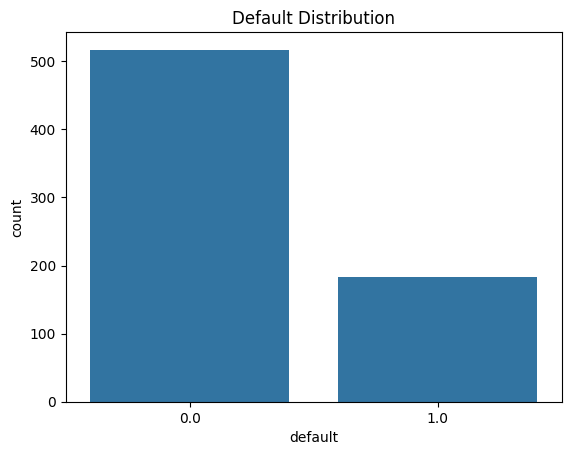

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

In [5]:
# Fill missing values
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_13038/2929704513.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop("default", axis=1)
y = df["default"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8176470588235294
[[125   8]
 [ 23  14]]
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       133
         1.0       0.64      0.38      0.47        37

    accuracy                           0.82       170
   macro avg       0.74      0.66      0.68       170
weighted avg       0.80      0.82      0.80       170



In [11]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


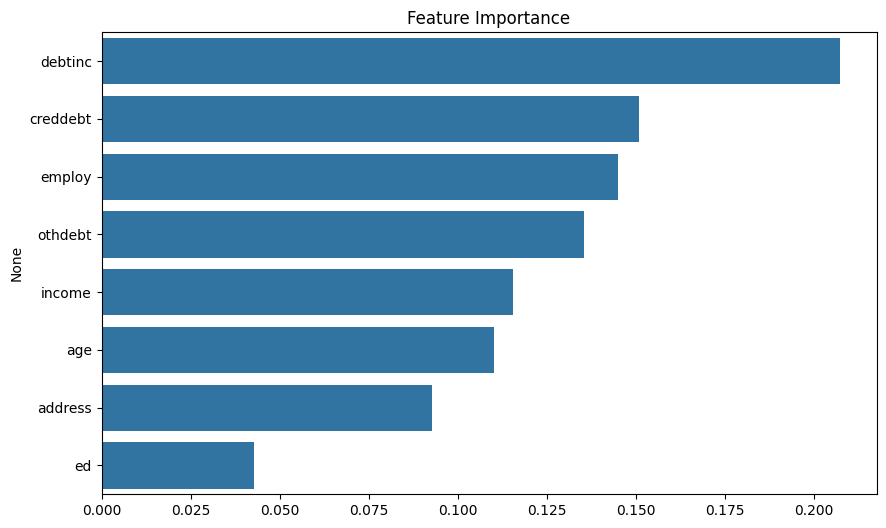

In [12]:
import numpy as np

importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices])
plt.title("Feature Importance")
plt.show()

In [13]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

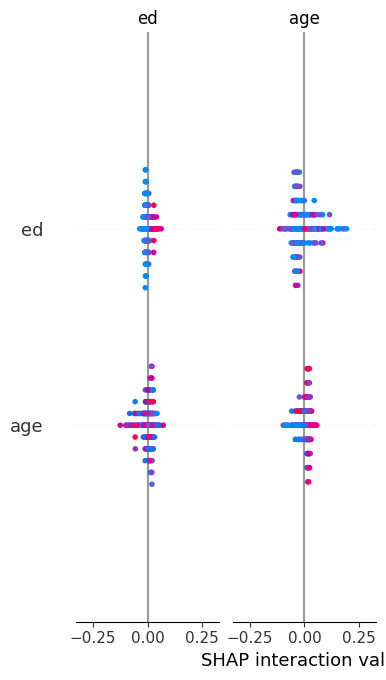

In [14]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.plots.waterfall(shap_values[0,1])

In [16]:
def predict_default(input_data):
    prediction = model.predict([input_data])
    return "Default" if prediction[0] == 1 else "No Default"

In [17]:
sample = X_test.iloc[0].values
print(predict_default(sample))

No Default


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Enter values to predict loan default")

user_input = []

for col in X.columns:
    val = float(input(f"{col}: "))
    user_input.append(val)

print("Prediction:", predict_default(user_input))

Enter values to predict loan default
